**Load Dataset**

In [1]:
import pandas as pd

# Load data
sentiment = pd.read_csv("fear_greed_index (1).csv")
trades = pd.read_csv("historical_data (1).csv")

# Preview
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

/tmp/ipykernel_12827/1797975357.py:5: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data (1).csv")


**Data Cleaning**

In [4]:
# Sentiment cleaning
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['classification'] = sentiment['classification'].str.lower().str.strip()
sentiment['date_only'] = sentiment['date'].dt.date

# Trader data cleaning
trades['time'] = pd.to_datetime(trades['Timestamp IST'], format="%d-%m-%Y %H:%M")
trades['date_only'] = trades['time'].dt.date

# Check missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())

# Remove duplicates
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)

timestamp         0
value             0
classification    0
date              0
date_only         0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
time                0
date_only           0
dtype: int64


**Create Key Metrices**

In [6]:
# Daily PnL per account
daily_pnl = trades.groupby(['Account', 'date_only'])['Closed PnL'].sum().reset_index()

# Trade count per day
trade_count = trades.groupby(['Account', 'date_only']).size().reset_index(name='trade_count')

# Average trade size
avg_size = trades.groupby(['Account', 'date_only'])['Size Tokens'].mean().reset_index()

# Merge all metrics
metrics = daily_pnl.merge(trade_count, on=['Account', 'date_only'])
metrics = metrics.merge(avg_size, on=['Account', 'date_only'])

**Merge with Sentiment**

In [8]:
merged = metrics.merge(sentiment[['date_only', 'classification']], on='date_only', how='inner')

print(merged.head())

                                      Account   date_only  Closed PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1   

   trade_count  Size Tokens classification  
0          177     1.587571  extreme greed  
1           68    16.176471  extreme greed  
2           40     7.500000  extreme greed  
3           12     8.333333  extreme greed  
4           27    74.074074  extreme greed  


**Analysis**

In [10]:
merged.groupby('classification')['Closed PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
extreme fear,127.0,3541.845572,30179.908679,-77308.420095,0.0,110.553364,2610.183590,229058.684298
extreme greed,499.0,5257.131585,28058.942236,-132271.000000,0.0,447.920315,2505.434851,449328.107544
fear,529.0,5270.488396,32946.271661,-108604.496278,0.0,93.006465,1334.414834,533974.662903
greed,602.0,2647.977055,27929.719215,-358963.139984,0.0,154.923518,1266.931278,375620.270243
neutral,344.0,3741.964602,16645.311664,-36229.641811,0.0,167.551743,1214.526174,194499.072534


In [12]:
merged.groupby('classification')[['trade_count', 'Size Tokens']].mean()

,trade_count,Size Tokens
classification,,
extreme fear,106.881890,2702.805688
extreme greed,75.877756,13075.435687
fear,87.200378,7554.774674
greed,74.606312,4840.692208
neutral,87.613372,6475.845363


In [14]:
print(merged.columns)

Index(['Account', 'date_only', 'Closed PnL', 'trade_count', 'Size Tokens',
       'classification'],
      dtype='object')


### Trader Segmentation

In [24]:
# 1. High vs. Low 'Leverage' Traders (using 'Size Tokens' as a proxy)
# Calculate the median 'Size Tokens' across all accounts
median_size_tokens = merged.groupby('Account')['Size Tokens'].mean().median()

def segment_size_tokens(account_avg_size):
    return 'high_size' if account_avg_size > median_size_tokens else 'low_size'

# Create a temporary DataFrame for average metrics per account
account_avg_metrics = merged.groupby('Account')[['Size Tokens', 'trade_count', 'Closed PnL']].mean().reset_index()

# Apply segmentation based on average 'Size Tokens'
account_avg_metrics['size_segment'] = account_avg_metrics['Size Tokens'].apply(segment_size_tokens)

# Merge this segment back to the original merged DataFrame (optional, for individual trade analysis)
# For simplicity, we'll keep the segmentation at the account level for now, or you can merge it like this:
merged = merged.merge(account_avg_metrics[['Account', 'size_segment']], on='Account', how='left')

print("Size Tokens Segmentation (proxy for leverage):")
print(merged['size_segment_x'].value_counts())

Size Tokens Segmentation (proxy for leverage):
size_segment_x
low_size     1067
high_size    1034
Name: count, dtype: int64


In [25]:
# 2. Frequent vs. Infrequent Traders
# Calculate the median 'trade_count' across all accounts
median_trade_count = merged.groupby('Account')['trade_count'].mean().median()

def segment_trade_count(account_avg_trade_count):
    return 'frequent' if account_avg_trade_count > median_trade_count else 'infrequent'

# Apply segmentation based on average 'trade_count'
account_avg_metrics['frequency_segment'] = account_avg_metrics['trade_count'].apply(segment_trade_count)

# Merge this segment back to the original merged DataFrame
merged = merged.merge(account_avg_metrics[['Account', 'frequency_segment']], on='Account', how='left')

print("\nTrade Frequency Segmentation:")
print(merged['frequency_segment_x'].value_counts())


Trade Frequency Segmentation:
frequency_segment_x
infrequent    1095
frequent      1006
Name: count, dtype: int64


In [26]:
# 3. Consistent Winners vs. Inconsistent Traders
# Calculate the median 'Closed PnL' across all accounts
# For simplicity, we define 'consistent winners' as accounts with a positive average PnL.
# You can adjust this threshold (e.g., median, a specific positive value) as needed.

# Recalculate average PnL if not already done, for fresh segmentation
account_avg_metrics['avg_pnl'] = merged.groupby('Account')['Closed PnL'].mean().reset_index(name='avg_pnl')['avg_pnl']

def segment_pnl(account_avg_pnl):
    return 'consistent_winner' if account_avg_pnl > 0 else 'inconsistent_trader'

# Apply segmentation based on average 'Closed PnL'
account_avg_metrics['pnl_segment'] = account_avg_metrics['avg_pnl'].apply(segment_pnl)

# Merge this segment back to the original merged DataFrame
merged = merged.merge(account_avg_metrics[['Account', 'pnl_segment']], on='Account', how='left')

print("\nPnL Segmentation:")
print(merged['pnl_segment_x'].value_counts())


PnL Segmentation:
pnl_segment_x
consistent_winner      1966
inconsistent_trader     135
Name: count, dtype: int64


In [22]:
# Display the first few rows of the merged DataFrame with new segments
print("\nMerged DataFrame with new segments:")
print(merged.head())


Merged DataFrame with new segments:
                                      Account   date_only  Closed PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11         0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17         0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18         0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22    -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26      1603.1   

   trade_count  Size Tokens classification size_segment_x frequency_segment_x  \
0          177     1.587571  extreme greed       low_size            frequent   
1           68    16.176471  extreme greed       low_size            frequent   
2           40     7.500000  extreme greed       low_size            frequent   
3           12     8.333333  extreme greed       low_size            frequent   
4           27    74.074074  extreme greed       low_size            frequent   

       pnl_segment_x size_segment_y f

**Charts**

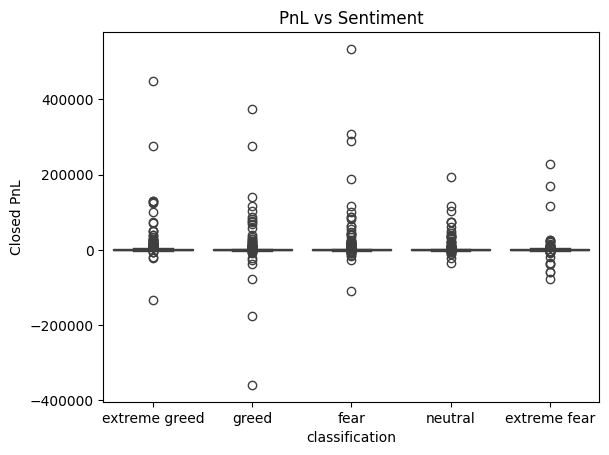

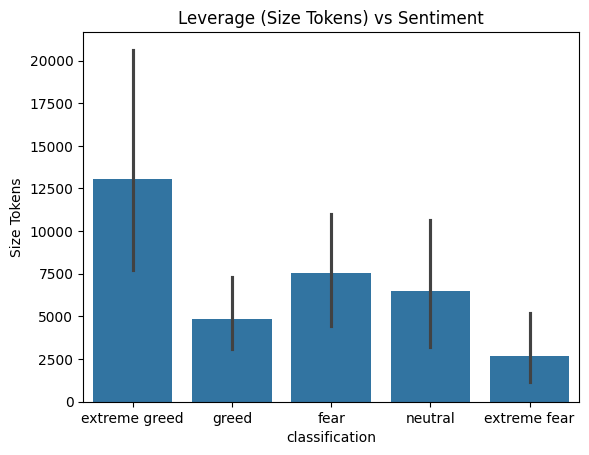

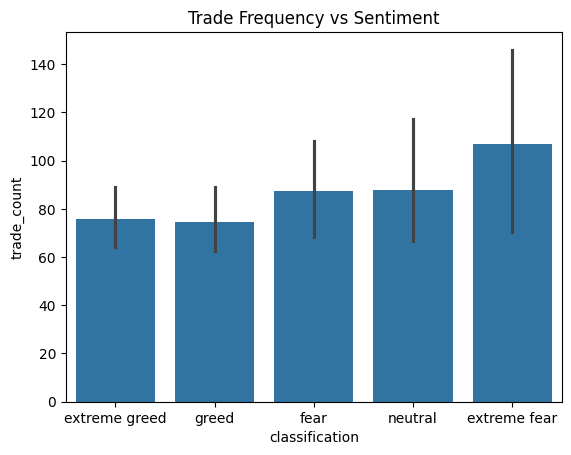

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# PnL distribution
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL vs Sentiment")
plt.show()

# Leverage (using Size Tokens as proxy)
sns.barplot(x='classification', y='Size Tokens', data=merged)
plt.title("Leverage (Size Tokens) vs Sentiment")
plt.show()

# Trade count
sns.barplot(x='classification', y='trade_count', data=merged)
plt.title("Trade Frequency vs Sentiment")
plt.show()